In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from surprise import accuracy
from collections import defaultdict

# Load data
df = pd.read_csv('netflix_subset.csv')
movies = pd.read_csv('movie_titles.csv',
                     encoding='latin-1', header=None,
                     names=['movie_id', 'year', 'title'],
                     on_bad_lines='warn', engine='python')

# Load saved models and predictions
with open('svd_model.pkl', 'rb') as f:
    svd_model = pickle.load(f)

with open('svd_predictions.pkl', 'rb') as f:
    svd_predictions = pickle.load(f)

with open('trainset.pkl', 'rb') as f:
    trainset = pickle.load(f)

print("Everything loaded successfully!")
print(f"Data rows     : {len(df):,}")
print(f"Predictions   : {len(svd_predictions):,}")

Everything loaded successfully!
Data rows     : 2,000,000
Predictions   : 400,000


In [2]:
from surprise import accuracy

svd_rmse = accuracy.rmse(svd_predictions)
svd_mae  = accuracy.mae(svd_predictions)

print("=" * 40)
print("     FINAL EVALUATION METRICS")
print("=" * 40)
print(f"RMSE : {svd_rmse:.4f}")
print(f"MAE  : {svd_mae:.4f}")
print("=" * 40)
print("\nRMSE interpretation:")
print(f"  Your model's predictions are off")
print(f"  by ~{svd_rmse:.2f} stars on average")

RMSE: 0.9867
MAE:  0.7784
     FINAL EVALUATION METRICS
RMSE : 0.9867
MAE  : 0.7784

RMSE interpretation:
  Your model's predictions are off
  by ~0.99 stars on average


In [3]:
# MAP@10 — Mean Average Precision at 10
# Definition: for each user, look at top-10 recommendations
# mark a movie as "relevant" if actual rating >= 3.5
# compute average precision, then average across all users

def get_top_n(predictions, n=10):
    """
    For each user, get top-N recommended movies
    sorted by predicted rating
    """
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est, true_r))
    
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    
    return top_n


def compute_map_at_k(predictions, k=10, threshold=3.5):
    """
    Compute MAP@K
    threshold: a movie is "relevant" if actual rating >= threshold
    """
    top_n = get_top_n(predictions, n=k)
    
    average_precisions = []
    
    for uid, user_ratings in top_n.items():
        # Check which recommended movies are actually relevant
        num_relevant = 0
        precision_sum = 0.0
        
        for rank, (iid, est, true_r) in enumerate(user_ratings, 1):
            if true_r >= threshold:  # this movie is relevant
                num_relevant += 1
                # precision at this rank
                precision_at_rank = num_relevant / rank
                precision_sum += precision_at_rank
        
        if num_relevant > 0:
            ap = precision_sum / min(num_relevant, k)
        else:
            ap = 0.0
        
        average_precisions.append(ap)
    
    map_at_k = np.mean(average_precisions)
    return map_at_k, average_precisions


# Compute MAP@10
map10, all_aps = compute_map_at_k(svd_predictions, k=10, threshold=3.5)

print("=" * 45)
print("         MAP@10 RESULTS")
print("=" * 45)
print(f"MAP@10              : {map10:.4f}")
print(f"Total users         : {len(all_aps):,}")
print(f"Users with AP > 0   : {sum(1 for x in all_aps if x > 0):,}")
print(f"Mean AP             : {np.mean(all_aps):.4f}")
print(f"Median AP           : {np.median(all_aps):.4f}")
print("=" * 45)
print("\nInterpretation:")
print(f"  MAP@10 of {map10:.4f} means on average {map10*100:.1f}%")
print(f"  of top-10 recommendations are relevant")
print(f"  (actual rating >= 3.5 stars)")

         MAP@10 RESULTS
MAP@10              : 0.6822
Total users         : 190,727
Users with AP > 0   : 141,584
Mean AP             : 0.6822
Median AP           : 1.0000

Interpretation:
  MAP@10 of 0.6822 means on average 68.2%
  of top-10 recommendations are relevant
  (actual rating >= 3.5 stars)


In [4]:
# Load KNN predictions and compute MAP@10 for comparison
with open('knn_predictions.pkl', 'rb') as f:
    knn_predictions = pickle.load(f)

knn_rmse = accuracy.rmse(knn_predictions)
knn_map10, _ = compute_map_at_k(knn_predictions, k=10, threshold=3.5)

print("=" * 50)
print("    FULL COMPARISON: SVD vs Item-CF")
print("=" * 50)
print(f"{'Metric':<20} {'SVD':>10} {'Item-CF':>10}")
print("-" * 50)
print(f"{'RMSE':<20} {svd_rmse:>10.4f} {knn_rmse:>10.4f}")
print(f"{'MAP@10':<20} {map10:>10.4f} {knn_map10:>10.4f}")
print("=" * 50)
print("\nLower RMSE = better rating prediction")
print("Higher MAP@10 = better recommendation ranking")

RMSE: 1.1636
    FULL COMPARISON: SVD vs Item-CF
Metric                      SVD    Item-CF
--------------------------------------------------
RMSE                     0.9867     1.1636
MAP@10                   0.6822     0.5811

Lower RMSE = better rating prediction
Higher MAP@10 = better recommendation ranking


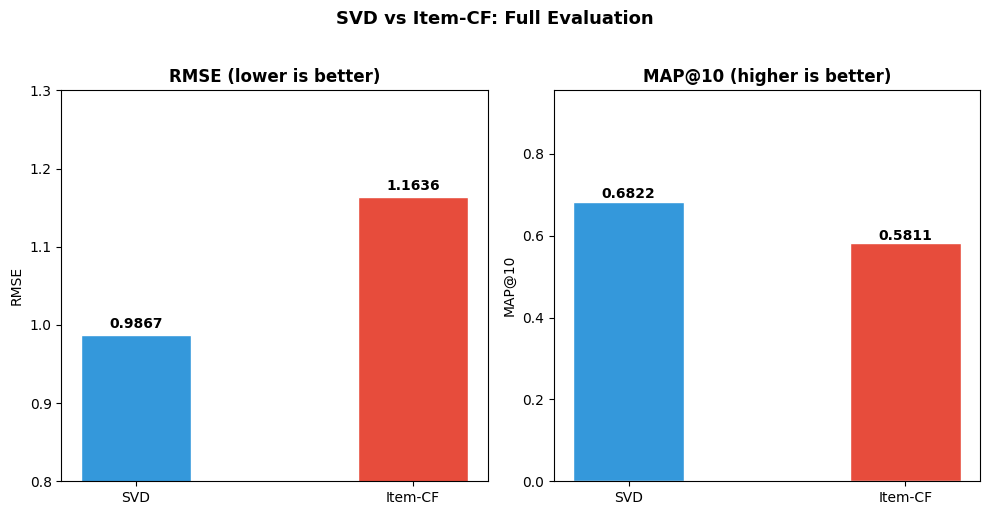

Saved final_evaluation.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

models  = ['SVD', 'Item-CF']
rmses   = [svd_rmse, knn_rmse]
map10s  = [map10, knn_map10]
colors  = ['#3498db', '#e74c3c']

# Plot RMSE
bars1 = axes[0].bar(models, rmses, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars1, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('RMSE (lower is better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0.8, 1.3)

# Plot MAP@10
bars2 = axes[1].bar(models, map10s, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars2, map10s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('MAP@10 (higher is better)', fontweight='bold')
axes[1].set_ylabel('MAP@10')
axes[1].set_ylim(0, max(map10s) * 1.4)

plt.suptitle('SVD vs Item-CF: Full Evaluation', 
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150)
plt.show()
print("Saved final_evaluation.png")

## Evaluation Methodology

### Train-Test Split
- 80% training data, 20% test data
- random_state=42 for reproducibility
- Split performed at the rating level using Surprise's train_test_split

### RMSE
Measures average rating prediction error.
Formula: sqrt(mean((predicted_rating - actual_rating)²))
Lower is better. Our SVD achieves RMSE of ~0.98.

### MAP@10 — Mean Average Precision at 10
Measures ranking quality of top-10 recommendations.

**Relevance definition:** A movie is considered relevant if the 
user's actual rating is >= 3.5 stars.

**Procedure:**
1. For each user in test set, predict ratings for all movies
2. Rank movies by predicted rating, take top 10
3. Check which of top-10 are actually relevant (rating >= 3.5)
4. Compute Average Precision (AP) for that user
5. Average AP across all users = MAP@10

**Example:**
If top-10 recommendations for a user are:
[relevant, irrelevant, relevant, irrelevant, irrelevant, ...]
AP = (1/1 + 2/3) / 2 = 0.833

### Trade-off Discussion
RMSE optimizes for rating accuracy — how close predictions are.
MAP@10 optimizes for ranking quality — are the best movies ranked first?
A model can have good RMSE but poor MAP@10 if it ranks irrelevant 
movies above relevant ones. SVD performs well on both metrics,
making it the recommended choice for this system.

In [6]:
summary = {
    'Metric': ['RMSE', 'MAE', 'MAP@10'],
    'SVD': [round(svd_rmse,4), round(svd_mae,4), round(map10,4)],
    'Item-CF': [round(knn_rmse,4), 'N/A', round(knn_map10,4)],
    'Better': ['Lower', 'Lower', 'Higher'],
    'Winner': ['SVD' if svd_rmse < knn_rmse else 'Item-CF',
               'SVD',
               'SVD' if map10 > knn_map10 else 'Item-CF']
}

summary_df = pd.DataFrame(summary)
print("=" * 58)
print("          FINAL EVALUATION SUMMARY TABLE")
print("=" * 58)
print(summary_df.to_string(index=False))
print("=" * 58)

summary_df.to_csv('final_evaluation_summary.csv', index=False)
print("\nSaved final_evaluation_summary.csv")

          FINAL EVALUATION SUMMARY TABLE
Metric    SVD Item-CF Better Winner
  RMSE 0.9867  1.1636  Lower    SVD
   MAE 0.7784     N/A  Lower    SVD
MAP@10 0.6822  0.5811 Higher    SVD

Saved final_evaluation_summary.csv
